# Carregamento dos Dados e Importações

## Importando as Bibliotecas

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Importando Modelos

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

## Importando Métricas

In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Carregando o Conjunto de Dados

In [5]:
df = pd.read_csv("../data/heart.csv")

# Pré-processamento

## Remoção de Inconsistências

In [6]:
print("Valores iguais a 0 nas variáveis numéricas:\n")

colunas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for coluna in colunas:
    qtd = (df[coluna] == 0).sum()
    perc = (qtd / len(df)) * 100

    print(f"{coluna}: {qtd} registros ({perc:.2f}%)")

Valores iguais a 0 nas variáveis numéricas:

Age: 0 registros (0.00%)
RestingBP: 1 registros (0.11%)
Cholesterol: 172 registros (18.74%)
MaxHR: 0 registros (0.00%)
Oldpeak: 368 registros (40.09%)


A variável `Oldpeak` mede a depressão. O valor 0 é clinicamente válido e indica ausência dessa alteração, portanto não foi tratado como inconsistência.

In [7]:
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)

df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())
df["RestingBP"] = df["RestingBP"].fillna(df["RestingBP"].median())

In [8]:
print("Valores iguais a 0 nas variáveis numéricas (depois do tratamento):\n")

colunas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

for coluna in colunas:
    qtd = (df[coluna] == 0).sum()
    perc = (qtd / len(df)) * 100

    print(f"{coluna}: {qtd} registros ({perc:.2f}%)")

Valores iguais a 0 nas variáveis numéricas (depois do tratamento):

Age: 0 registros (0.00%)
RestingBP: 0 registros (0.00%)
Cholesterol: 0 registros (0.00%)
MaxHR: 0 registros (0.00%)
Oldpeak: 368 registros (40.09%)


## Tratamento de Outliers

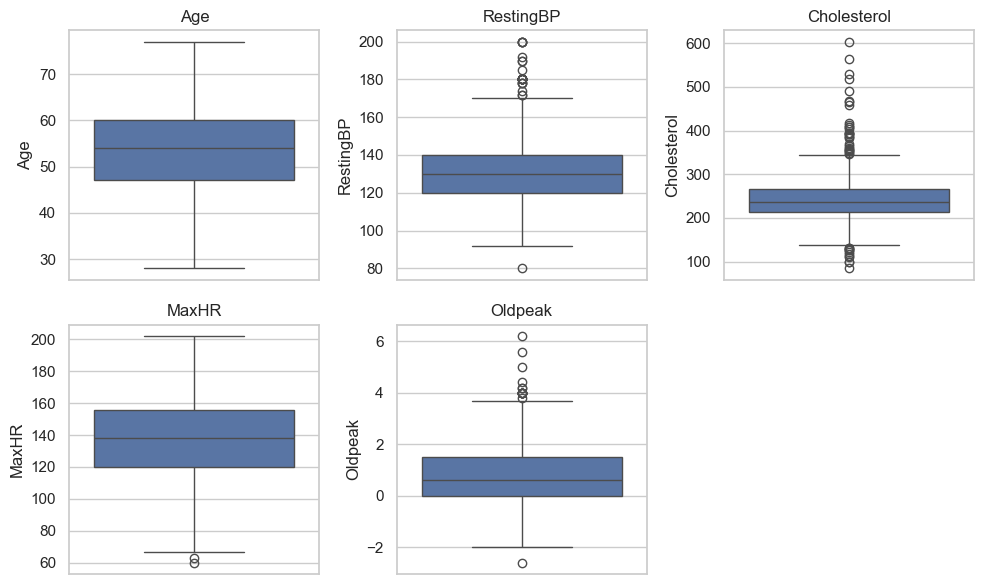

In [9]:
colunas_numericas = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

plt.figure(figsize=(10, 6))

for i, col in enumerate(colunas_numericas):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [10]:
outliers = {}

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    qtd_outliers = df[(df[col] < inferior) | (df[col] > superior)].shape[0]

    outliers[col] = qtd_outliers

outliers

{'Age': 0, 'RestingBP': 27, 'Cholesterol': 41, 'MaxHR': 2, 'Oldpeak': 16}

In [11]:
df_limpo = df.copy()

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR

    df_limpo[col] = np.where(df[col] < inferior, inferior, df[col])
    df_limpo[col] = np.where(df[col] > superior, superior, df[col])

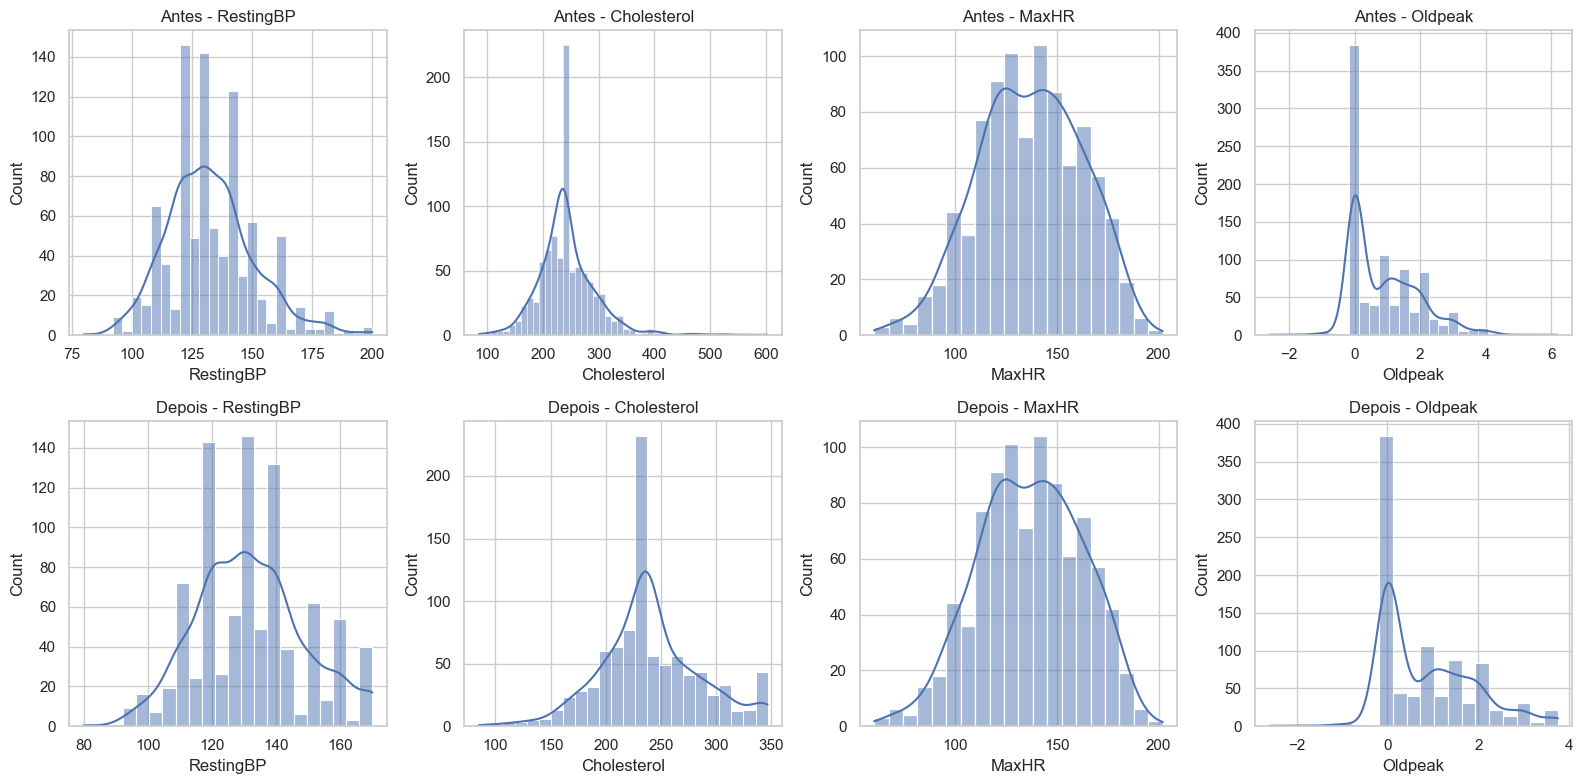

In [12]:
colunas = ["RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(colunas):
    sns.histplot(df[col], kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"Antes - {col}")

    sns.histplot(df_limpo[col], kde=True, ax=axes[1, i])
    axes[1, i].set_title(f"Depois - {col}")

plt.tight_layout()
plt.show()

## Encoding das Variáveis Categóricas

In [13]:
df_encoded = pd.get_dummies(df_limpo, drop_first=True)

df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40.0,140.0,289.0,0,172.0,0.0,0,True,True,False,False,True,False,False,False,True
1,49.0,160.0,180.0,0,156.0,1.0,1,False,False,True,False,True,False,False,True,False
2,37.0,130.0,283.0,0,98.0,0.0,0,True,True,False,False,False,True,False,False,True
3,48.0,138.0,214.0,0,108.0,1.5,1,False,False,False,False,True,False,True,True,False
4,54.0,150.0,195.0,0,122.0,0.0,0,True,False,True,False,True,False,False,False,True


In [14]:
df_encoded = df_encoded.astype(int)

df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


## Normalização / Padronização

In [15]:
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

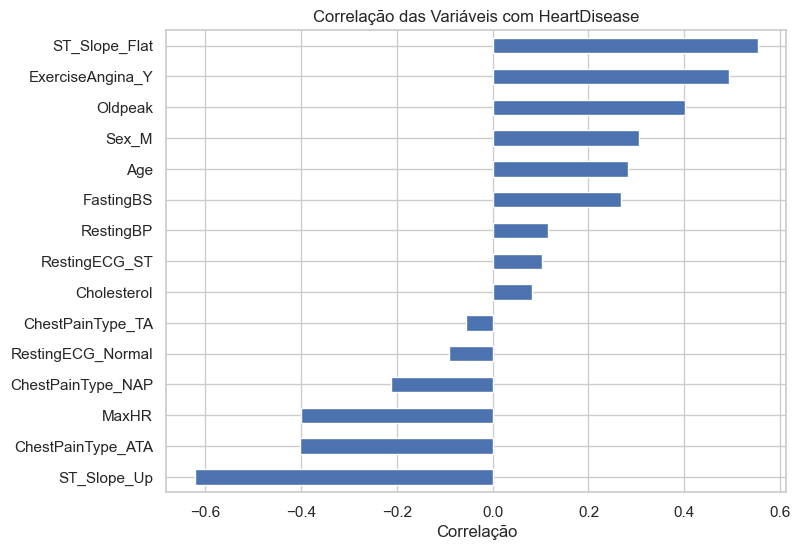

In [18]:
df_corr = df_encoded.corr()

plt.figure(figsize=(8,6))

df_corr["HeartDisease"].drop("HeartDisease").sort_values().plot(kind="barh")

plt.title("Correlação das Variáveis com HeartDisease")
plt.xlabel("Correlação")

plt.show()

# Modelagem

## Instanciando os Modelos

In [19]:
modelos = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

## Treinamento dos Modelos

In [20]:
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


# Avaliação

## Definindo Métricas de Avaliação

In [21]:
resultados = []

for nome, modelo in modelos.items():

    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

resultados_df = pd.DataFrame(resultados)

resultados_df

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.875000,0.883495,0.892157,0.887805,0.933405
1,KNN,0.885870,0.885714,0.911765,0.898551,0.927666
2,SVM,0.869565,0.867925,0.901961,0.884615,0.942013
3,Random Forest,0.869565,0.875000,0.892157,0.883495,0.933764
4,XGBoost,0.858696,0.880000,0.862745,0.871287,0.908537


In [22]:
print(resultados_df)

                Modelo  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.875000   0.883495  0.892157  0.887805  0.933405
1                  KNN  0.885870   0.885714  0.911765  0.898551  0.927666
2                  SVM  0.869565   0.867925  0.901961  0.884615  0.942013
3        Random Forest  0.869565   0.875000  0.892157  0.883495  0.933764
4              XGBoost  0.858696   0.880000  0.862745  0.871287  0.908537


## Visualização das Métricas

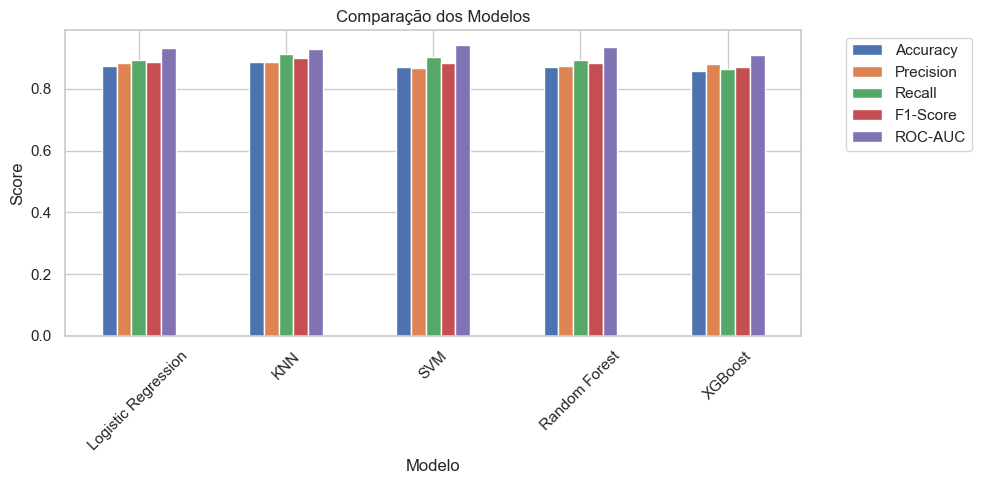

In [23]:
resultados_df.set_index("Modelo").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparação dos Modelos")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## Ranking dos Modelos por cada Métrica Avaliada

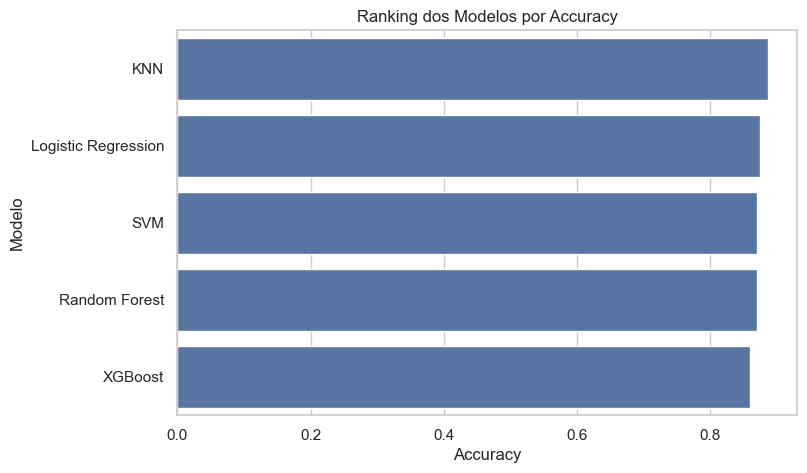

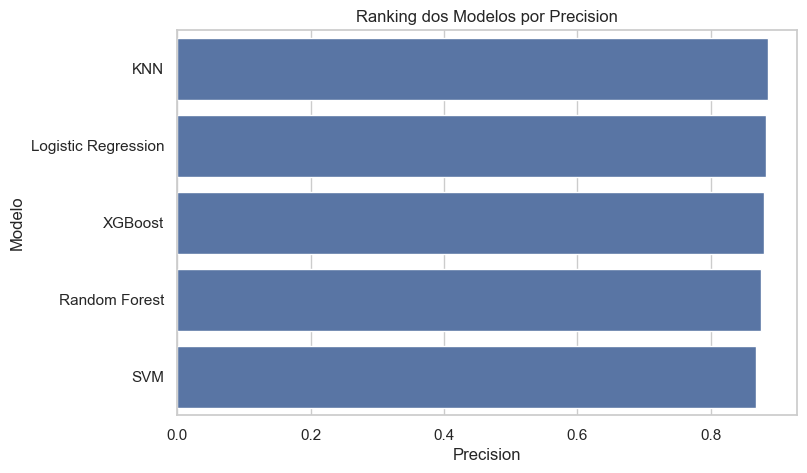

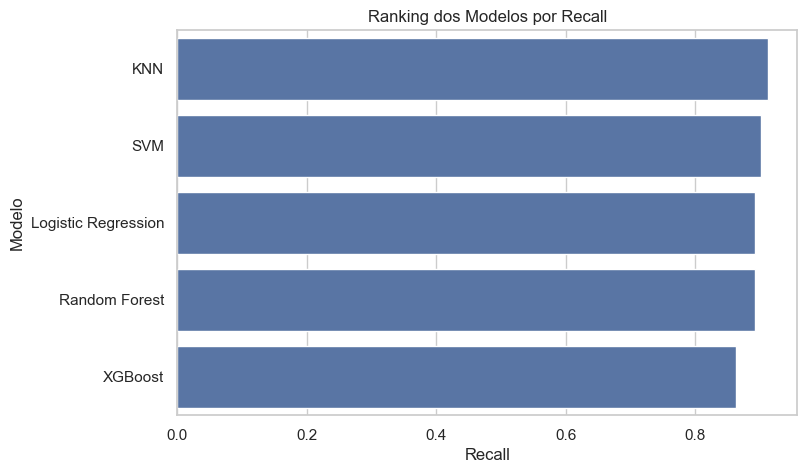

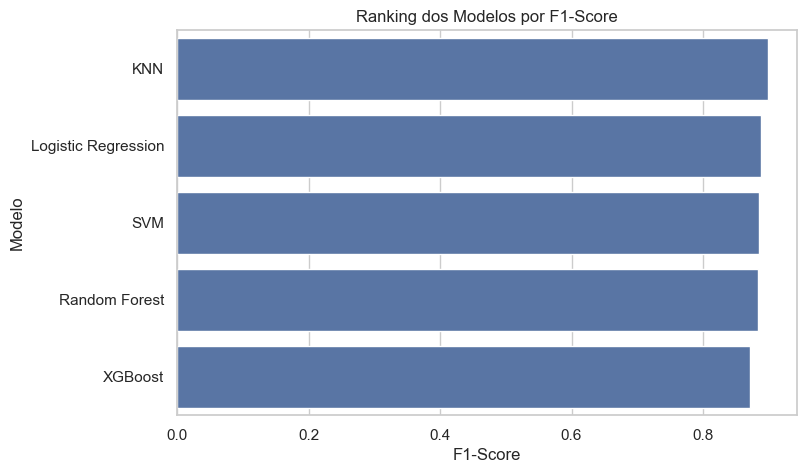

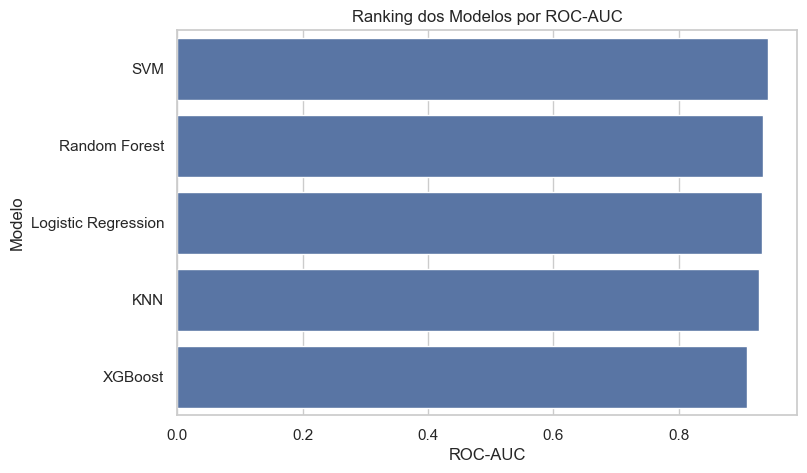

In [24]:
metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

for metrica in metricas:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=resultados_df.sort_values(metrica, ascending=False),
        x=metrica,
        y="Modelo"
    )

    plt.title(f"Ranking dos Modelos por {metrica}")

    plt.show()

# Interpretação dos Resultados e Conclusão

## Melhor Modelo para o Problema: KNN

> Após a avaliação dos cinco modelos de machine learning, o KNN foi selecionado como o modelo final deste projeto por apresentar o melhor desempenho geral. O algoritmo alcançou a maior Accuracy (88,59%), indicando a maior taxa de classificações corretas, além do maior Recall (91,18%), demonstrando excelente capacidade de identificar pacientes com doença cardíaca. O modelo também obteve o maior F1-Score (89,86%), evidenciando um bom equilíbrio entre precisão e sensibilidade.

> Embora o SVM tenha apresentado o maior valor de ROC-AUC (94,20%), a diferença em relação aos demais modelos foi pequena. Por outro lado, o KNN manteve resultados superiores nas métricas mais relevantes para o problema de classificação, especialmente na identificação correta de pacientes com a doença. Dessa forma, considerando o conjunto das métricas avaliadas, o KNN foi escolhido como a melhor solução para a predição de doença cardíaca neste conjunto de dados.


### Matriz de Confusão do KNN

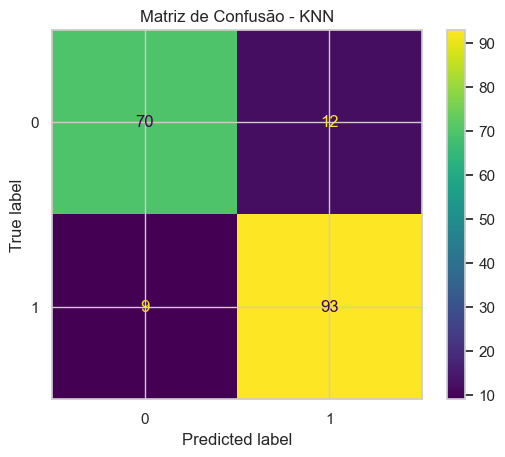

In [25]:
knn = modelos["KNN"]

y_pred = knn.predict(X_test)

ConfusionMatrixDisplay.from_estimator(
    knn,
    X_test,
    y_test
)

plt.title("Matriz de Confusão - KNN")

plt.show()

### Acertos x Erros do KNN

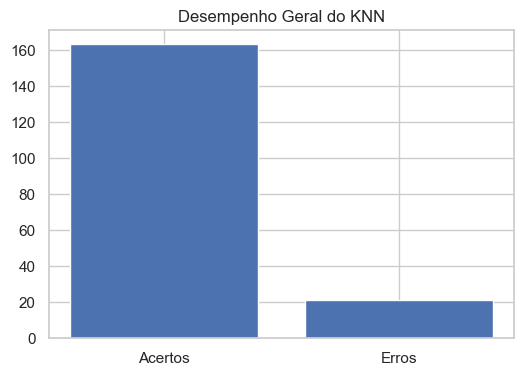

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

acertos = cm[0,0] + cm[1,1]
erros = cm[0,1] + cm[1,0]

plt.figure(figsize=(6,4))

plt.bar(
    ["Acertos", "Erros"],
    [acertos, erros]
)

plt.title("Desempenho Geral do KNN")

plt.show()

Os resultados obtidos mostram que o conjunto de dados possui características relevantes para a identificação de doenças cardíacas, permitindo que os modelos de Machine Learning alcancem um bom desempenho preditivo. A comparação entre diferentes algoritmos evidenciou a importância da etapa de avaliação, já que cada modelo apresentou pontos fortes em métricas específicas. Dessa forma, o projeto atingiu seu objetivo de desenvolver e comparar modelos de classificação, identificando o KNN como a alternativa mais adequada para este conjunto de dados.

Salvando o Modelo Treinado e Testado

In [27]:
print(X.columns.tolist())

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [29]:
import joblib

modelo_final = modelos["KNN"]

joblib.dump(modelo_final, "../model/knn_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']